In [1]:
#Impports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
# Get raw data
df = pd.read_csv("Euroleague_Stats.csv")
df

,#
0,Player
1,Team
2,GP
3,Min
4,eFG%
...,...
2282,19.30%
2283,13.60%
2284,33.40%
2285,27.90%


In [3]:
#Reshape data
data = df.iloc[:,0].values
num_cols = 16
num_rows = len(data)//num_cols
reshaped_data = data[:num_rows * num_cols].reshape(num_rows,num_cols)
df_transformed = pd.DataFrame(reshaped_data)
df_transformed.columns = df_transformed.iloc[0]
df_transformed = df_transformed[1:].reset_index(drop = True)
df = df_transformed
df.head()


,Player,Team,GP,Min,eFG%,TS%,OREB%,DREB%,REB%,AST/TO,AST-R,TO-R,2PTA-R,3PTA-R,FT-RT,1
0,A. ABALDE,"VBC, RMB",165,17:49,52.30%,55.40%,3.60%,13.40%,8.60%,2.1,21.30%,10.20%,31.30%,31.20%,21.70%,1
1,A. ABRINES,FCB,163,17:19,62.40%,65%,4.10%,9.70%,7%,1.4,10.10%,7.10%,19.90%,57.20%,16.70%,1
2,J. ANDERSON,EFS,134,14:33,56.60%,59.80%,6%,15.80%,11.10%,1.6,13.60%,8.40%,35.20%,34.70%,26.20%,1
3,W. BALDWIN IV,"OLY, BAY, BKN, MTA, FBB",170,25:58:00,49.20%,54.40%,1.70%,11.80%,6.70%,1.6,21.10%,12.90%,39.40%,18.30%,32.70%,1
4,B. BARON,"CZV, ZEN, EA7",121,21:48,56.60%,60.80%,1.30%,10.10%,5.70%,1.7,17%,10.10%,22.10%,43.40%,25.70%,1


In [4]:
#Imports for web scraping
import requests
from bs4 import BeautifulSoup

In [ ]:
# Scrape web for positions


In [4]:
df.describe()

,Player,Team,GP,Min,eFG%,TS%,OREB%,DREB%,REB%,AST/TO,AST-R,TO-R,2PTA-R,3PTA-R,FT-RT,1
count,141,141,141,141,141,141,141,141,141,141,141,141,141,141,141,141
unique,140,111,88,134,93,102,76,89,93,26,109,71,119,119,119,1
top,D. HALL,EFS,134,17:49,55.70%,58.20%,1.30%,11.80%,5.70%,1.6,10.10%,10.70%,35.20%,0%,40.60%,1
freq,2,6,4,2,4,4,6,5,4,16,4,5,3,5,4,141


In [5]:
df = df[['Player', 'Team', 'GP', 'eFG%', 'OREB%', 'TO-R', 'FT-RT']]
df.head()

,Player,Team,GP,eFG%,OREB%,TO-R,FT-RT
0,A. ABALDE,"VBC, RMB",165,52.30%,3.60%,10.20%,21.70%
1,A. ABRINES,FCB,163,62.40%,4.10%,7.10%,16.70%
2,J. ANDERSON,EFS,134,56.60%,6%,8.40%,26.20%
3,W. BALDWIN IV,"OLY, BAY, BKN, MTA, FBB",170,49.20%,1.70%,12.90%,32.70%
4,B. BARON,"CZV, ZEN, EA7",121,56.60%,1.30%,10.10%,25.70%


In [6]:
df['FT-RT'] = pd.to_numeric(df['FT-RT'].str.rstrip('%'), errors='coerce') / 100
df['TO-R'] = pd.to_numeric(df['TO-R'].str.rstrip('%'), errors='coerce') / 100
df['eFG%'] = pd.to_numeric(df['eFG%'].str.rstrip('%'), errors='coerce') / 100
df['OREB%'] = pd.to_numeric(df['OREB%'].str.rstrip('%'), errors='coerce') / 100

C:\Users\swimm\AppData\Local\Temp\ipykernel_2332\2377881976.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['FT-RT'] = pd.to_numeric(df['FT-RT'].str.rstrip('%'), errors='coerce') / 100
C:\Users\swimm\AppData\Local\Temp\ipykernel_2332\2377881976.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['TO-R'] = pd.to_numeric(df['TO-R'].str.rstrip('%'), errors='coerce') / 100
C:\Users\swimm\AppData\Local\Temp\ipykernel_2332\2377881976.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy o

In [7]:
df_plots = df[['eFG%','OREB%', 'TO-R', 'FT-RT']]

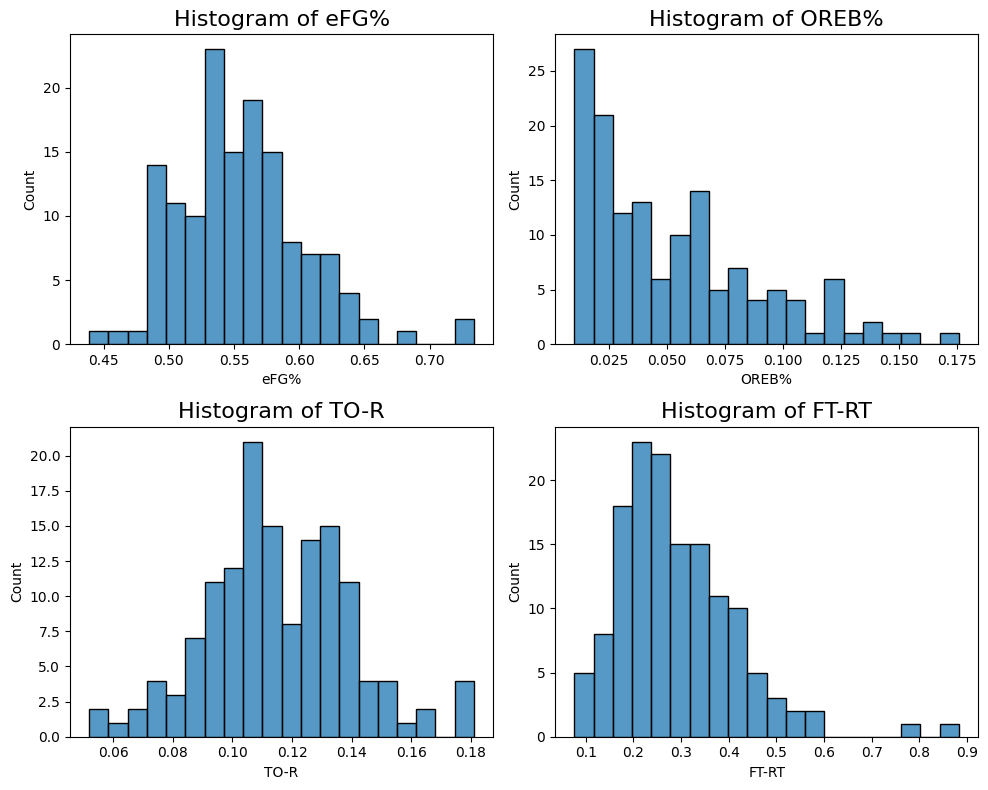

In [8]:
fig,axes = plt.subplots(2,2, figsize = (10,8))
axes = axes.flatten()
for i, col in enumerate(df_plots.columns):
    sb.histplot(df_plots[col], bins = 20, kde = False, ax = axes[i])
    axes[i].set_title(f'Histogram of {col}', fontsize = 16)
    
plt.tight_layout()
plt.show()

In [9]:
#Standardize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

features = ['eFG%', 'OREB%', 'TO-R', 'FT-RT']

std_df = df.copy()
std_df[features] = scaler.fit_transform(std_df[features])

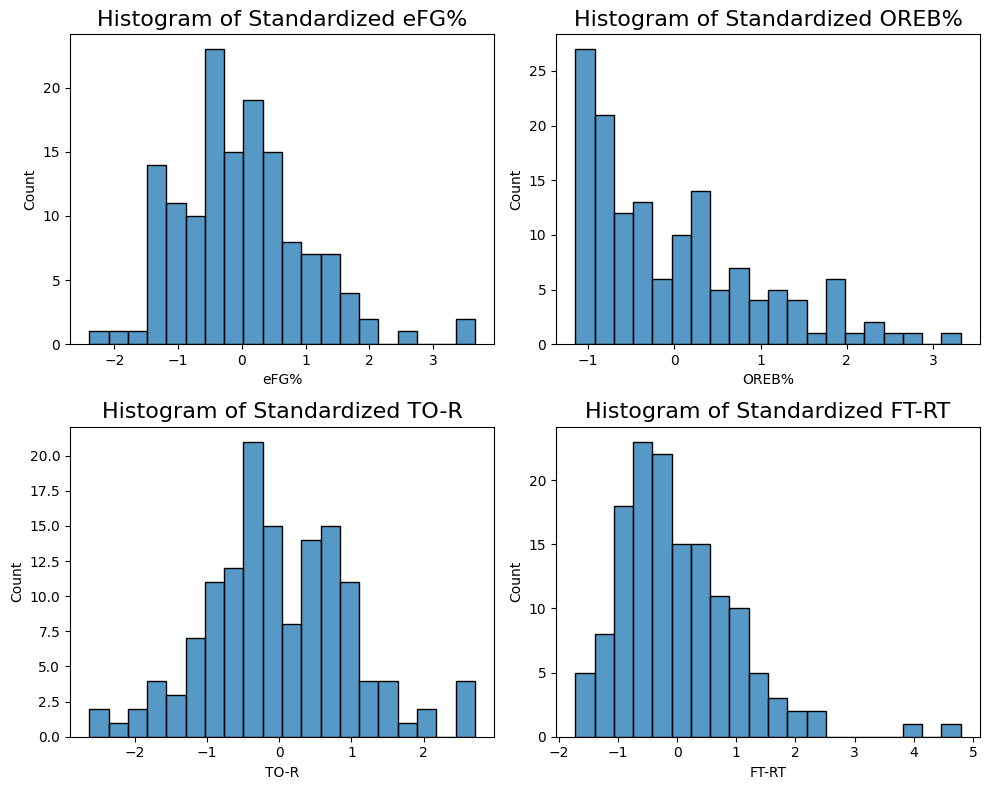

In [10]:
std_df_features = std_df[['eFG%', 'OREB%', 'TO-R', 'FT-RT']]
fig,axes = plt.subplots(2,2, figsize = (10,8))
axes = axes.flatten()
for i, col in enumerate(std_df_features.columns):
    sb.histplot(std_df_features[col], bins = 20, kde = False, ax = axes[i])
    axes[i].set_title(f'Histogram of Standardized {col}', fontsize = 16)
    
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Boxplot for Relevant Euroleague Player Statistics')

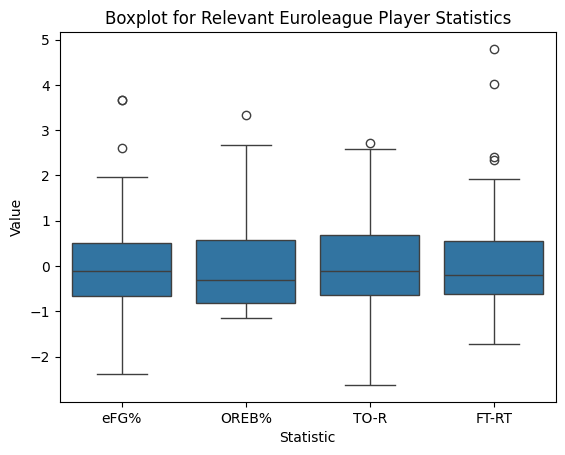

In [11]:
df_melted = std_df_features.melt(var_name='Statistic', value_name='Value')
sb.boxplot(x = 'Statistic', y = 'Value', data = df_melted)
plt.title("Boxplot for Relevant Euroleague Player Statistics")

<Axes: xlabel='0', ylabel='0'>

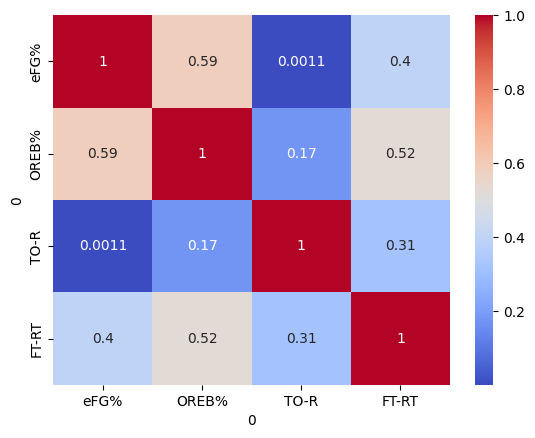

In [12]:
corr = df.corr(numeric_only = True)
sb.heatmap(corr, cmap="coolwarm", annot=True)

In [13]:
df.to_csv("Euro_data_clean.csv", index = False)